# Crowdedness at the Campus Gym Prediction

| Column Name | Description |
|-------------|-------------|
| date | Datetime of the data |
| timestamp | Number of seconds since the beginning of the day |
| day_of_week | Day of the week (0 = Monday, 6 = Sunday) |
| is_weekend | Indicates whether the day is a weekend (0 = No, 1 = Yes) |
| is_holiday | Indicates whether the day is a federal holiday (0 = No, 1 = Yes) |
| temperature | Temperature in degrees Fahrenheit |
| is_start_of_semester | Indicates whether it is the beginning of a school semester (0 = No, 1 = Yes) |
| month | Month of the year (1 = January, 12 = December) |
| hour | Hour of the day (0–23) |

In [203]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings


plt.rcParams["figure.figsize"] = (16, 8)
sns.set_style("darkgrid")
warnings.filterwarnings("ignore")

In [204]:
df = pd.read_csv("data.csv")

In [205]:
df.head()

,number_people,date,timestamp,day_of_week,is_weekend,is_holiday,temperature,is_start_of_semester,is_during_semester,month,hour
0,37,2015-08-14 17:00:11-07:00,61211,4,0,0,71.76,0,0,8,17
1,45,2015-08-14 17:20:14-07:00,62414,4,0,0,71.76,0,0,8,17
2,40,2015-08-14 17:30:15-07:00,63015,4,0,0,71.76,0,0,8,17
3,44,2015-08-14 17:40:16-07:00,63616,4,0,0,71.76,0,0,8,17
4,45,2015-08-14 17:50:17-07:00,64217,4,0,0,71.76,0,0,8,17


In [206]:
df.shape

(62184, 11)

In [207]:
df.describe()

,number_people,timestamp,day_of_week,is_weekend,is_holiday,temperature,is_start_of_semester,is_during_semester,month,hour
count,62184.000000,62184.000000,62184.000000,62184.000000,62184.000000,62184.000000,62184.000000,62184.000000,62184.000000,62184.000000
mean,29.072543,45799.437958,2.982504,0.282870,0.002573,58.557108,0.078831,0.660218,7.439824,12.236460
std,22.689026,24211.275891,1.996825,0.450398,0.050660,6.316396,0.269476,0.473639,3.445069,6.717631
min,0.000000,0.000000,0.000000,0.000000,0.000000,38.140000,0.000000,0.000000,1.000000,0.000000
25%,9.000000,26624.000000,1.000000,0.000000,0.000000,55.000000,0.000000,0.000000,5.000000,7.000000
50%,28.000000,46522.500000,3.000000,0.000000,0.000000,58.340000,0.000000,1.000000,8.000000,12.000000
75%,43.000000,66612.000000,5.000000,1.000000,0.000000,62.280000,0.000000,1.000000,10.000000,18.000000
max,145.000000,86399.000000,6.000000,1.000000,1.000000,87.170000,1.000000,1.000000,12.000000,23.000000


In [208]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62184 entries, 0 to 62183
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   number_people         62184 non-null  int64  
 1   date                  62184 non-null  object 
 2   timestamp             62184 non-null  int64  
 3   day_of_week           62184 non-null  int64  
 4   is_weekend            62184 non-null  int64  
 5   is_holiday            62184 non-null  int64  
 6   temperature           62184 non-null  float64
 7   is_start_of_semester  62184 non-null  int64  
 8   is_during_semester    62184 non-null  int64  
 9   month                 62184 non-null  int64  
 10  hour                  62184 non-null  int64  
dtypes: float64(1), int64(9), object(1)
memory usage: 5.2+ MB


In [209]:
df.isnull().sum()

number_people           0
date                    0
timestamp               0
day_of_week             0
is_weekend              0
is_holiday              0
temperature             0
is_start_of_semester    0
is_during_semester      0
month                   0
hour                    0
dtype: int64

In [210]:
df.columns.to_list()

['number_people',
 'date',
 'timestamp',
 'day_of_week',
 'is_weekend',
 'is_holiday',
 'temperature',
 'is_start_of_semester',
 'is_during_semester',
 'month',
 'hour']

In [211]:
df["date"][0].split(" ")

['2015-08-14', '17:00:11-07:00']

In [212]:
df["date"] = pd.to_datetime(df["date"], utc= True)

In [213]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62184 entries, 0 to 62183
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype              
---  ------                --------------  -----              
 0   number_people         62184 non-null  int64              
 1   date                  62184 non-null  datetime64[ns, UTC]
 2   timestamp             62184 non-null  int64              
 3   day_of_week           62184 non-null  int64              
 4   is_weekend            62184 non-null  int64              
 5   is_holiday            62184 non-null  int64              
 6   temperature           62184 non-null  float64            
 7   is_start_of_semester  62184 non-null  int64              
 8   is_during_semester    62184 non-null  int64              
 9   month                 62184 non-null  int64              
 10  hour                  62184 non-null  int64              
dtypes: datetime64[ns, UTC](1), float64(1), int64(9)
memory usage: 5.2 M

In [214]:
df

,number_people,date,timestamp,day_of_week,is_weekend,is_holiday,temperature,is_start_of_semester,is_during_semester,month,hour
0,37,2015-08-15 00:00:11+00:00,61211,4,0,0,71.76,0,0,8,17
1,45,2015-08-15 00:20:14+00:00,62414,4,0,0,71.76,0,0,8,17
2,40,2015-08-15 00:30:15+00:00,63015,4,0,0,71.76,0,0,8,17
3,44,2015-08-15 00:40:16+00:00,63616,4,0,0,71.76,0,0,8,17
4,45,2015-08-15 00:50:17+00:00,64217,4,0,0,71.76,0,0,8,17
...,...,...,...,...,...,...,...,...,...,...,...
62179,23,2017-03-19 01:42:28+00:00,67348,5,1,0,61.07,0,1,3,18
62180,21,2017-03-19 01:52:35+00:00,67955,5,1,0,61.07,0,1,3,18
62181,25,2017-03-19 02:02:40+00:00,68560,5,1,0,56.71,0,1,3,19
62182,18,2017-03-19 02:12:47+00:00,69167,5,1,0,56.71,0,1,3,19


In [215]:
df["year"] = df["date"].dt.year

In [216]:
df

,number_people,date,timestamp,day_of_week,is_weekend,is_holiday,temperature,is_start_of_semester,is_during_semester,month,hour,year
0,37,2015-08-15 00:00:11+00:00,61211,4,0,0,71.76,0,0,8,17,2015
1,45,2015-08-15 00:20:14+00:00,62414,4,0,0,71.76,0,0,8,17,2015
2,40,2015-08-15 00:30:15+00:00,63015,4,0,0,71.76,0,0,8,17,2015
3,44,2015-08-15 00:40:16+00:00,63616,4,0,0,71.76,0,0,8,17,2015
4,45,2015-08-15 00:50:17+00:00,64217,4,0,0,71.76,0,0,8,17,2015
...,...,...,...,...,...,...,...,...,...,...,...,...
62179,23,2017-03-19 01:42:28+00:00,67348,5,1,0,61.07,0,1,3,18,2017
62180,21,2017-03-19 01:52:35+00:00,67955,5,1,0,61.07,0,1,3,18,2017
62181,25,2017-03-19 02:02:40+00:00,68560,5,1,0,56.71,0,1,3,19,2017
62182,18,2017-03-19 02:12:47+00:00,69167,5,1,0,56.71,0,1,3,19,2017


In [217]:
df.drop("date", axis= 1, inplace= True)

In [218]:
df.head()

,number_people,timestamp,day_of_week,is_weekend,is_holiday,temperature,is_start_of_semester,is_during_semester,month,hour,year
0,37,61211,4,0,0,71.76,0,0,8,17,2015
1,45,62414,4,0,0,71.76,0,0,8,17,2015
2,40,63015,4,0,0,71.76,0,0,8,17,2015
3,44,63616,4,0,0,71.76,0,0,8,17,2015
4,45,64217,4,0,0,71.76,0,0,8,17,2015


## Exploratory Data Analysis(EDA)

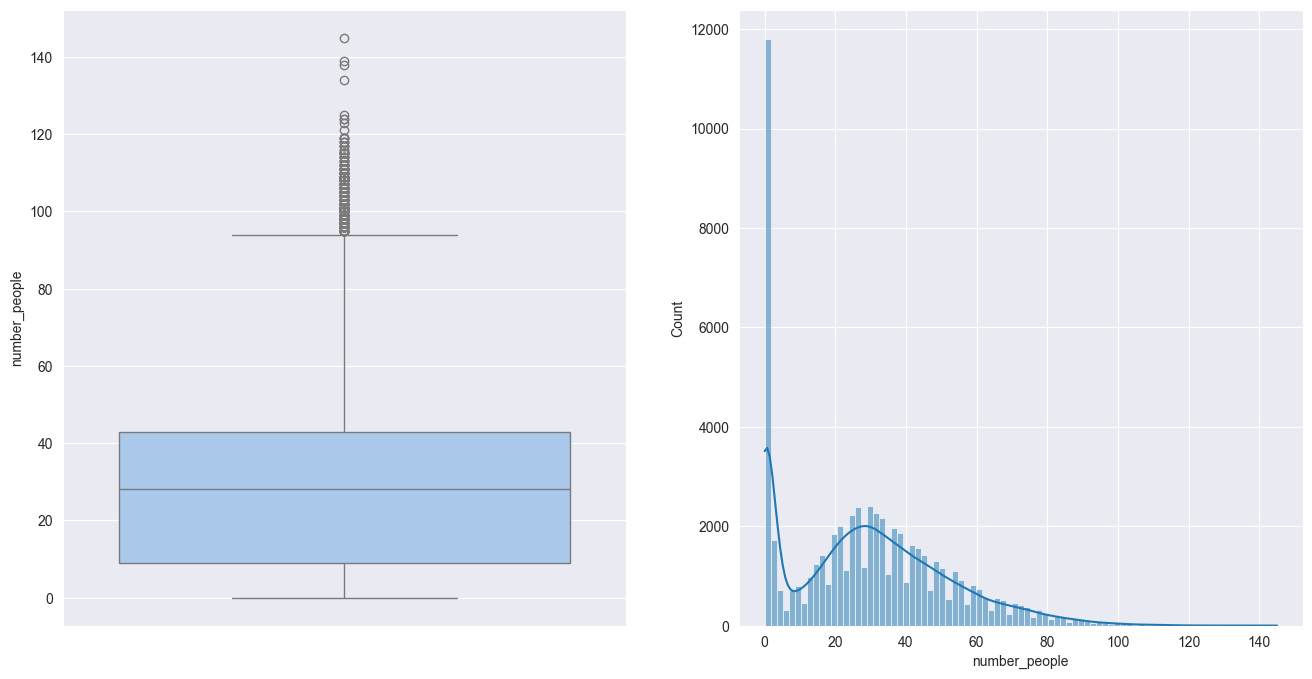

In [219]:
fig, ax = plt.subplots(1, 2)

sns.histplot(df["number_people"], kde= True, ax= ax[1])

# 0 kişi yoğunluğu çok fazla, muhtemelen salonun gece ,sabaha karşı ve ya kapalı vakitlerini temsil ediyor olabilir
# Grafik sağa çarpıktır, yüksek kalabalıklık daha seyrek gözükmektedir
# Yaklaşık 100 kişinin üstündeki kalabalıklık az görülmektedir

sns.boxplot(df["number_people"], ax= ax[0], palette= "pastel")
plt.show()

# Salon kalabalıklığı genelllikle yaklaşık 40 ila 25 kişi arasında değişmektedir
# Median(Ortanca Değer) yaklaşık 30 kişidir
# Dağılımım üst kısmında dikkate değer sayıda aykırı değer bulunmaktadır
# Aykırı değerler dışında verinin çoğunluğu yaklaşık 0 ile 100 kişi arasında yer almaktadır

In [220]:
q1, q2, q3 = df["number_people"].quantile([0.25, 0.5, 0.75])

iqr = q3 - q1

upper_bound = q3 + (iqr * 1.5)
lower_bound = 0

skew = df["number_people"].skew()
kurt = df["number_people"].kurt()

print(f"Q1 (1. Çeyrek) : {q1:.2f}")
print(f"Q2 (Medyan) : {q2:.2f}")
print(f"Q3 (3. Çeyrek) : {q3:.2f}")
print(f"IQR (Çeyrekler Arası Açıklık): {iqr:.2f}")
print(f"Alt Sınır : {lower_bound:.2f}")
print(f"Üst Sınır : {upper_bound:.2f}")
print(f"Çarpıklık (Skewness) : {skew:.2f}")
print(f"Basıklık (Kurtosis): {kurt:.2f}")

Q1 (1. Çeyrek) : 9.00
Q2 (Medyan) : 28.00
Q3 (3. Çeyrek) : 43.00
IQR (Çeyrekler Arası Açıklık): 34.00
Alt Sınır : 0.00
Üst Sınır : 94.00
Çarpıklık (Skewness) : 0.57
Basıklık (Kurtosis): -0.06


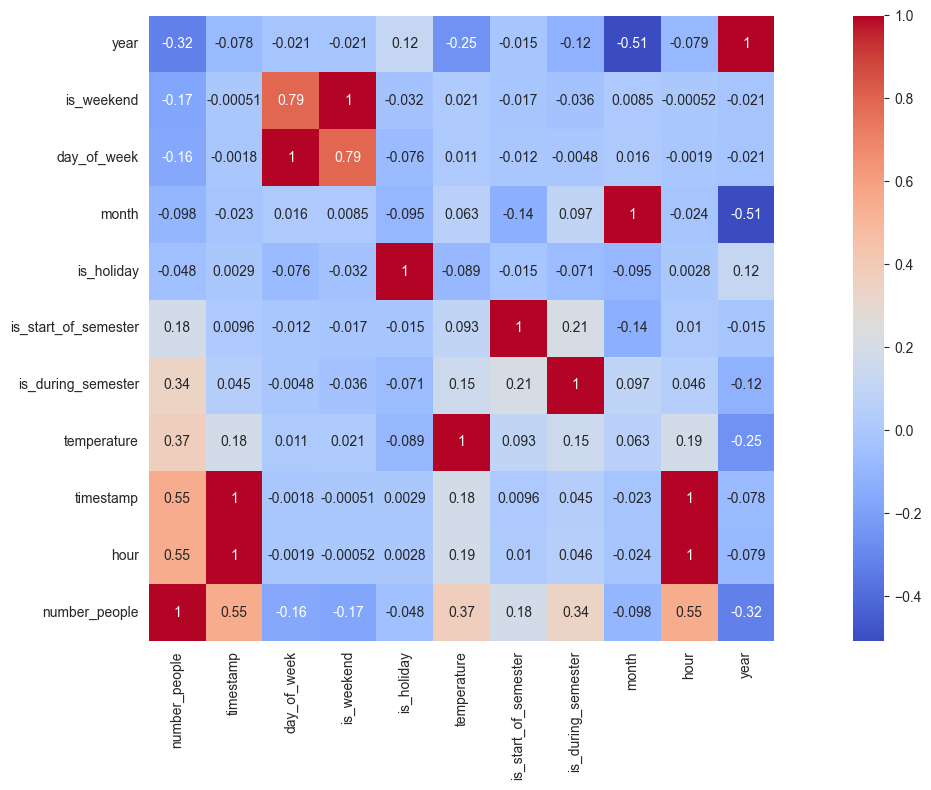

In [221]:
corr = df.corr().sort_values(by= "number_people")

sns.heatmap(corr, cmap= "coolwarm", square= True, annot= True)

plt.tight_layout()
plt.show()

In [222]:
df["hour"].nunique()

24

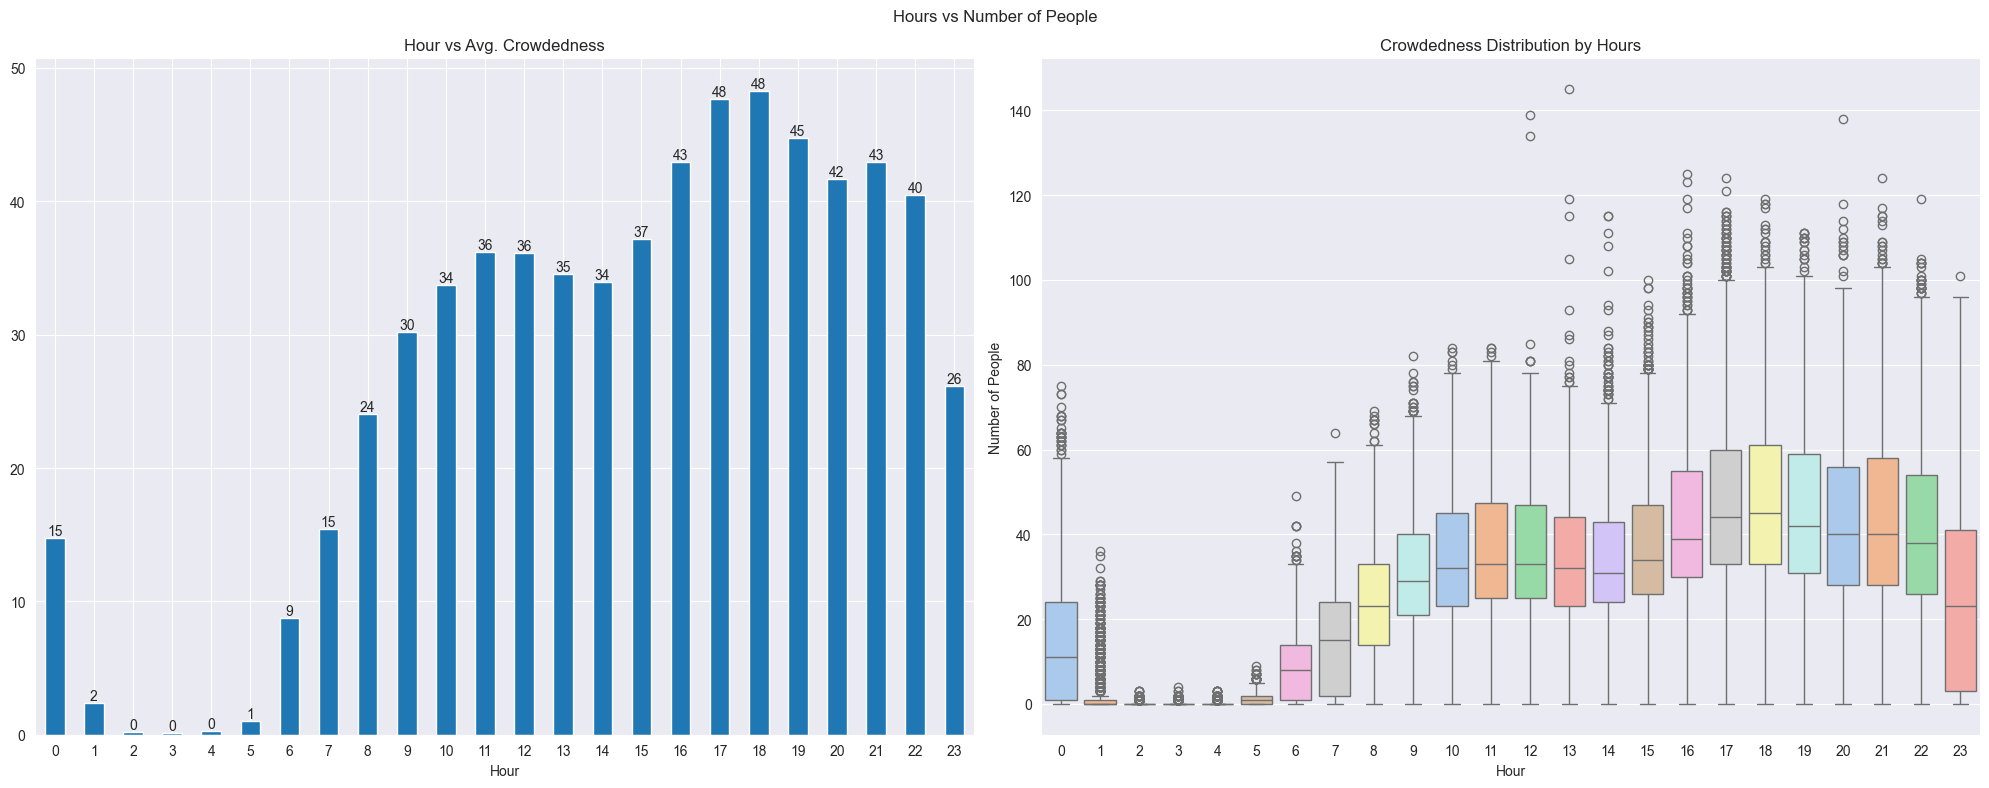

In [223]:
fig, ax = plt.subplots(1, 2, figsize = (20, 8))

# Saatlere göre Salon Yoğunluğu Ortalaması

hourly_avg = df.groupby("hour")["number_people"].mean()
hourly_avg.plot(kind= "bar", ax= ax[0])

ax[0].tick_params(axis = "x", rotation = 0)
ax[0].set_title("Hour vs Avg. Crowdedness")
ax[0].set_xlabel("Hour")

for container in ax[0].containers:
    ax[0].bar_label(container, fmt= "%.0f")

# Salon yoğunluğu en fazla saat 17 ve 18'de gözlemlenmekte.
# Salon yoğunluğu en az saat 2, 3 ve 4'te gözlemlenmekte.

sns.boxplot(
    data= df,
    x= "hour",
    y= "number_people",
    palette= "pastel",
    ax= ax[1]
)

ax[1].set_title("Crowdedness Distribution by Hours")
ax[1].set_ylabel("Number of People")
ax[1].set_xlabel("Hour")


plt.suptitle("Hours vs Number of People")

plt.tight_layout()
plt.show()

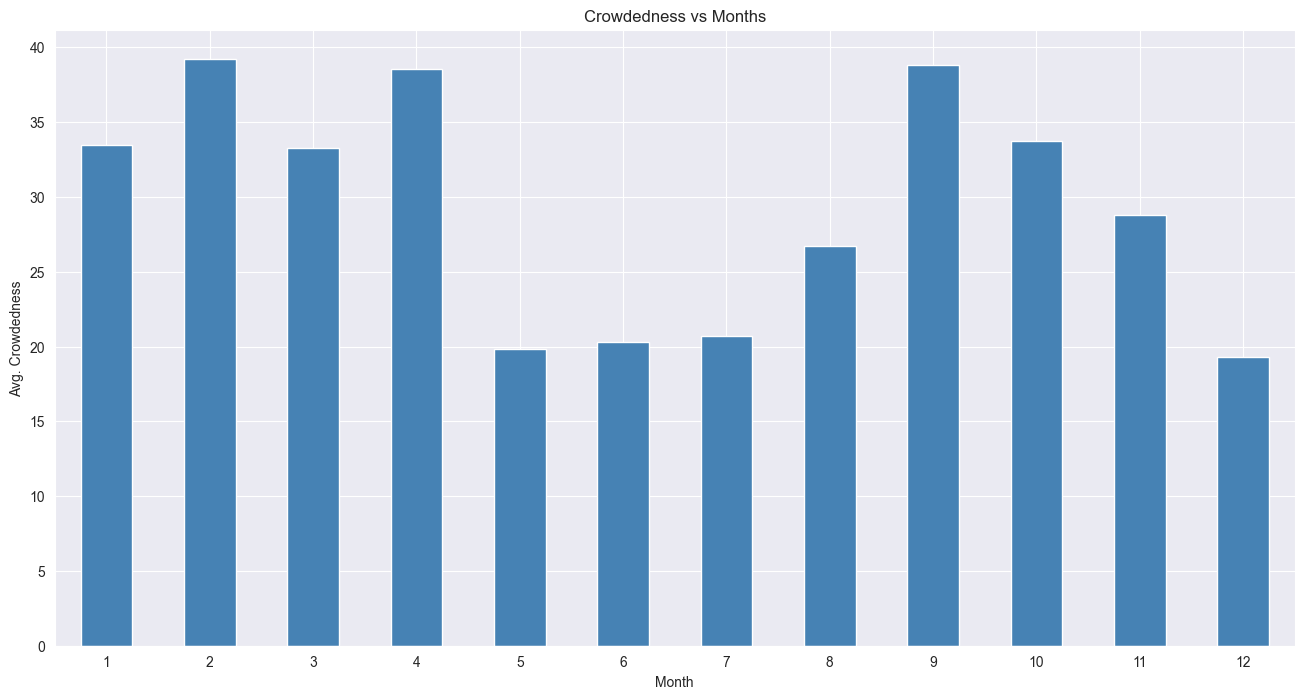

In [224]:
# Aylara göre Kalabalıklık Ortalaması
# Crowdedness Avg. by Months

monthly_avg = df.groupby("month")["number_people"].mean()

monthly_avg.plot(kind="bar", color="steelblue")

plt.title("Crowdedness vs Months")
plt.xlabel("Month")
plt.ylabel("Avg. Crowdedness")
plt.xticks(rotation=0)
plt.show()

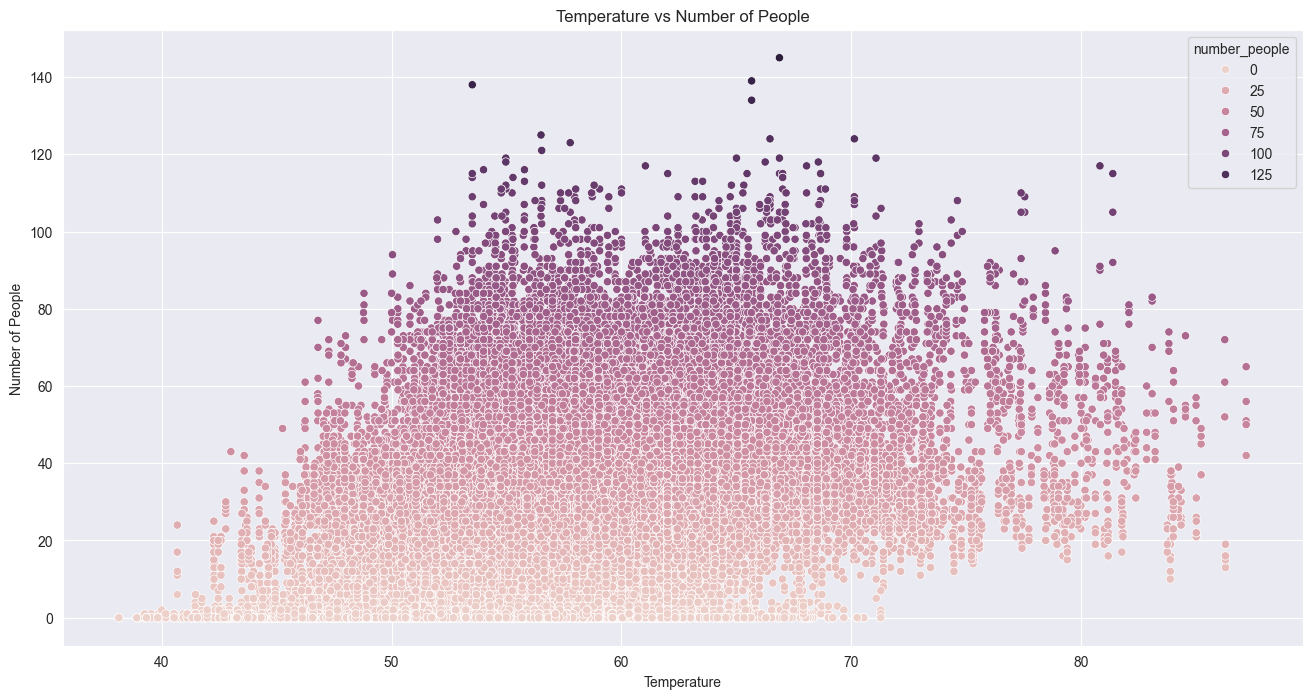

In [225]:
sns.scatterplot(
    data= df,
    x= "temperature",
    y= "number_people",
    hue= "number_people"
)

plt.title("Temperature vs Number of People")
plt.ylabel("Number of People")
plt.xlabel("Temperature")

plt.show()

## Preprocessing

In [226]:
df.drop("timestamp", axis = 1, inplace = True)

In [227]:
df.head()

,number_people,day_of_week,is_weekend,is_holiday,temperature,is_start_of_semester,is_during_semester,month,hour,year
0,37,4,0,0,71.76,0,0,8,17,2015
1,45,4,0,0,71.76,0,0,8,17,2015
2,40,4,0,0,71.76,0,0,8,17,2015
3,44,4,0,0,71.76,0,0,8,17,2015
4,45,4,0,0,71.76,0,0,8,17,2015


In [228]:
# Dependent # Independent feaure
X = df.drop("number_people", axis = 1)
y = df["number_people"]

In [229]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state= 42)

In [230]:
from sklearn.preprocessing import StandardScaler

x_scaler = StandardScaler()
y_scaler = StandardScaler()

In [231]:
X_train = x_scaler.fit_transform(X_train)
X_test = x_scaler.transform(X_test)

y_train = y_scaler.fit_transform(y_train.values.reshape(-1, 1))
y_test = y_scaler.transform(y_test.values.reshape(-1, 1))

## Model Training and Model Comparison

In [232]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [233]:
rfRegressor = RandomForestRegressor()
linear = LinearRegression()
knRegressor = KNeighborsRegressor()
ridge = Ridge()
lasso = Lasso()
svr = SVR()
dtRegressor = DecisionTreeRegressor()

In [234]:
models = {"Random Forest Regressor" : rfRegressor,
         "Linear Regression" : linear,
         "K-Neighbors Regressor" : knRegressor,
         "Ridge" :ridge,
         "Lasso" : lasso,
         "Support Vector Regressor" :svr,
         "Decision Tree Regressor": dtRegressor}

In [235]:
def calculate_model_metrics(models):
        for key, model in models.items():
            print(f"{key}\n")

            model.fit(X_train, y_train)

            y_train_predicts = model.predict(X_train)
            y_test_predicts = model.predict(X_test)

            print("Train Prediction Metrics\n")
            print(f"R2 Score : {r2_score(y_train, y_train_predicts):.2%}")
            print(f"MSE : {mean_squared_error(y_train, y_train_predicts)}")
            print(f"MAE : {mean_absolute_error(y_train, y_train_predicts)}\n")

            print("Test Prediction Metrics\n")
            print(f"R2 Score : {r2_score(y_test, y_test_predicts):.2%}")
            print(f"MSE : {mean_squared_error(y_test, y_test_predicts)}")
            print(f"MAE : {mean_absolute_error(y_test, y_test_predicts)}")
            print("=" * 60)

In [236]:
calculate_model_metrics(models)

Random Forest Regressor

Train Prediction Metrics

R2 Score : 95.53%
MSE : 0.044699534603414984
MAE : 0.14349716088351247

Test Prediction Metrics

R2 Score : 92.58%
MSE : 0.07462195419784465
MAE : 0.18500998461674956
Linear Regression

Train Prediction Metrics

R2 Score : 59.82%
MSE : 0.40182126977189714
MAE : 0.4745228372246023

Test Prediction Metrics

R2 Score : 60.59%
MSE : 0.3960770049377778
MAE : 0.4699512314855374
K-Neighbors Regressor

Train Prediction Metrics

R2 Score : 94.43%
MSE : 0.05566451888751274
MAE : 0.15889843686183833

Test Prediction Metrics

R2 Score : 90.78%
MSE : 0.09270650350414837
MAE : 0.20533145320786497
Ridge

Train Prediction Metrics

R2 Score : 59.82%
MSE : 0.4018212700483607
MAE : 0.4745231680025196

Test Prediction Metrics

R2 Score : 60.59%
MSE : 0.3960769857034086
MAE : 0.469951704207298
Lasso

Train Prediction Metrics

R2 Score : 0.00%
MSE : 0.9999999999999996
MAE : 0.8059725907698829

Test Prediction Metrics

R2 Score : -0.00%
MSE : 1.0050204476455

In [237]:
#Hyperparameter Tunning

In [238]:
rf_params = {
    "n_estimators" : [100, 200, 500],
    "max_depth" : [10, 50, 100, None],
    "max_features" : ["sqrt", "log2"],
    "min_samples_split" : [2, 3, 5, 10 , 20],
}

kn_params = {
    "n_neighbors" : [3, 5, 7, 10, 15],
    "weights" : ["uniform", "distance"],
    "p" : [1, 2]
}

# svr_params = {
#     "kernel" : ["linear", "rbf", "sigmoid"],
#     "gamma" :  ["scale", "auto"],
#     "C" : [1, 3, 5, 10]
# }

In [239]:
from sklearn.model_selection import RandomizedSearchCV

In [240]:
randomcv_models = [
    ("KNN", KNeighborsRegressor(), kn_params),
    ("Random Forest", RandomForestRegressor(), rf_params),
    # ("Support Vector Regressor", SVR(), svr_params)
]

In [242]:
for name, model, params in randomcv_models:
    print(name)
    randomcv = RandomizedSearchCV(
        estimator= model,
        param_distributions= params,
        cv= 5,
        n_iter= 100,
        n_jobs= -1
    )

    randomcv.fit(X_train, y_train)

    print(f"Best model for {name} : {randomcv.best_params_}")
    print("=" * 60)
    

KNN
Best model for KNN : {'weights': 'distance', 'p': 1, 'n_neighbors': 10}
Random Forest
Best model for Random Forest : {'n_estimators': 500, 'min_samples_split': 3, 'max_features': 'log2', 'max_depth': 100}


In [ ]:
models = {
    "K-Neighbors Regressor" : KNeighborsRegressor(
        weights= "distance",
        p= 1,
        n_neighbors= 10
    ),
    "Random Forest Regressor" : RandomForestRegressor(
        n_estimators = 500,
        min_samples_split = 3,
        max_features = 'log2',
        max_depth = 50
    )
}

In [ ]:
calculate_model_metrics(models)

K-Neighbors Regressor

Train Prediction Metrics

R2 Score : 95.58%
MSE : 0.04424239854217566
MAE : 0.14221658345470906

Test Prediction Metrics

R2 Score : 92.29%
MSE : 0.07745295045704635
MAE : 0.18704189568724158
Random Forest Regressor

Train Prediction Metrics

R2 Score : 95.53%
MSE : 0.0446639915347014
MAE : 0.14360252994037326

Test Prediction Metrics

R2 Score : 92.63%
MSE : 0.07407818373087337
MAE : 0.18477779058764354
